In [13]:
#Question 7.1
import numpy as np
from numpy import linalg as la
from numpy.linalg import inv

A = np.array([1,2, 3,0,-4,1,0,3,-1]).reshape(3,3)
print (A)
det = la.det(A)
print(f"Determinant of A is: {det:.6f}")

b = np.array([2,2,1]) #Ax=b
Ainv = inv(A)
xyz = Ainv@b
print(f"\nSolution: x, y, z = {xyz}")

Atrans =A.T #For orthogonal : Ainv=Atrans
print(f"\nIs A orthogonal? " ,{np.allclose(Atrans, Ainv)})

Lambda, v = la.eig(A)
print("\nLambda = ", Lambda)
print(f"Eigenvectors:\n{v}")

[[ 1  2  3]
 [ 0 -4  1]
 [ 0  3 -1]]
Determinant of A is: 1.000000

Solution: x, y, z = [ 38.  -3. -10.]

Is A orthogonal?  {False}

Lambda =  [ 1.         -4.79128785 -0.20871215]
Eigenvectors:
[[ 1.         -0.05055961  0.94256676]
 [ 0.         -0.78318743 -0.08518794]
 [ 0.          0.6197267  -0.32297201]]


In [24]:
import numpy as np 
from numpy import linalg as la
from math import *
from numpy.linalg import norm

E = np.array([
    [-0.06698874, -0.87275577, -0.48353891],
    [ 0.49272847, -0.45034696,  0.74458463],
    [-0.86760081, -0.18837460,  0.46019978]
])
def Ey(degb):
    b=np.radians(degb)
    Ey= np.array([np.cos(b), 0 , -np.sin(b),0,1,0,np.sin(b),0,np.cos(b)]).reshape(3,3)
    return Ey
def Ez(degg):
    g=np.radians(degg)
    Ez= np.array([np.cos(g),np.sin(g),0,-np.sin(g),np.cos(g),0,0,0,1]).reshape(3,3)
    return Ez
Etot = la.multi_dot([Ez(180-123),Ey(90-27.4),Ez(192.25)])
print(E)
print(f"\nall dotted is Etot=\n{Etot}")

[[-0.06698874 -0.87275577 -0.48353891]
 [ 0.49272847 -0.45034696  0.74458463]
 [-0.86760081 -0.1883746   0.46019978]]

all dotted is Etot=
[[-0.06698874 -0.87275577 -0.48353891]
 [ 0.49272847 -0.45034696  0.74458463]
 [-0.86760081 -0.1883746   0.46019978]]


In [14]:
import numpy as np

E = np.array([
    [-0.06698874, -0.87275577, -0.48353891],
    [ 0.49272847, -0.45034696,  0.74458463],
    [-0.86760081, -0.18837460,  0.46019978]
])

is_rot_matrix = np.allclose(E.T @ E, np.eye(3)) and np.isclose(np.linalg.det(E), 1.0)
print(is_rot_matrix)

evals, _ = np.linalg.eig(E)
has_eig_one = np.any(np.isclose(evals, 1.0 + 0.0j))
print(has_eig_one)

alpha, delta = np.radians(192.25), np.radians(27.4)
v = np.array([
    np.cos(delta) * np.cos(alpha),
    np.cos(delta) * np.sin(alpha),
    np.sin(delta)
])
print(v)

print(np.isclose(np.linalg.norm(v), 1.0))

v2 = E @ v
print(np.allclose(v2, [0, 0, 1]))

True
True
[-0.86760081 -0.1883746   0.46019978]
True
True


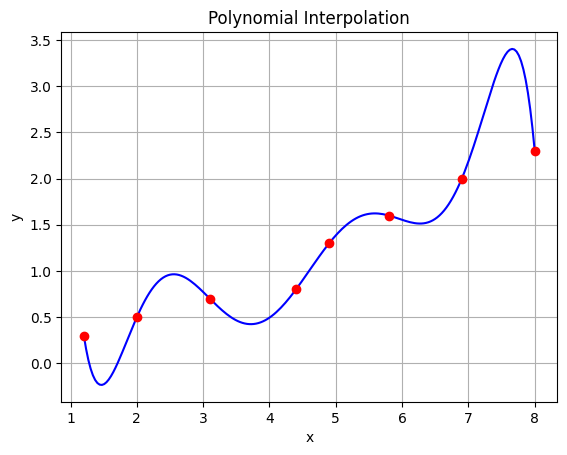

In [5]:
#Question 7.5
import numpy as np
import matplotlib.pyplot as plt
x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3])

n=len(x)
A=np.zeros((n,n))

for i in range(n):
    for j in range (n):
        A[i,j]=x[i]**j
coeffs = np.linalg.solve(A,y)

x_plot = np.linspace(np.min(x), np.max(x),200)
y_plot = np.zeros_like(x_plot)

for j in range (n):
    y_plot += coeffs[j] *(x_plot**j)

plt.figure()
plt.scatter(x,y,color = 'red', label = 'Data points',zorder = 5)
plt.plot (x_plot, y_plot, color='blue', label = 'Interpolating Poly')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Polynomial Interpolation')
plt.grid()
plt.show()


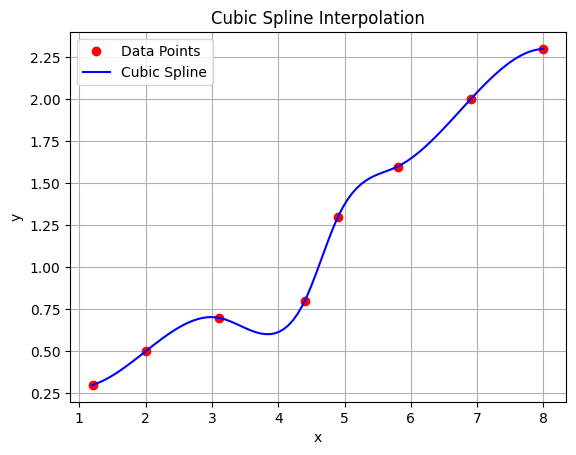

Unlike high-degree polynomials which can oscillate wildly near the edges of the domain, cubic splines provide a smooth and stable interpolation across the entire range.
Results for X_hat = 4.0:
Linear Y_hat:     0.7692
Polynomial Y_hat: 0.4937
Spline Y_hat:     0.6141


In [6]:
#question 7.6
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, lagrange

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3])

#1
f_cubic = interp1d(x, y, kind='cubic')
x_plot = np.linspace(x.min(), x.max(), 100)
y_cubic = f_cubic(x_plot)

plt.figure()
plt.plot(x, y, 'ro', label='Data Points')
plt.plot(x_plot, y_cubic, 'b-', label='Cubic Spline')
plt.title('Cubic Spline Interpolation')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid()
plt.show()
#2
print("Unlike high-degree polynomials which can oscillate wildly near the edges of the domain, cubic splines provide a smooth and stable interpolation across the entire range.")
# 3 & 4
class interpolation:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        
        # Linear
        self.func_linear = interp1d(x, y, kind='linear')
        # poly
        self.func_poly = lagrange(x, y)
        # Spline
        self.func_spline = interp1d(x, y, kind='cubic')
        
    def evaluate(self, X_hat, method):
        if method == 'linear':
            return self.func_linear(X_hat)
        elif method == 'polynomial':
            return self.func_poly(X_hat)
        elif method == 'spline':
            return self.func_spline(X_hat)
        else:
            raise ValueError("Invalid method. Choose 'linear', 'polynomial', or 'spline'.")

interp_obj = interpolation(x, y)
#5
X_hat = 4.0

y_hat_linear = interp_obj.evaluate(X_hat, method='linear')
y_hat_poly = interp_obj.evaluate(X_hat, method='polynomial')
y_hat_spline = interp_obj.evaluate(X_hat, method='spline')

print(f"Results for X_hat = {X_hat}:")
print(f"Linear Y_hat:     {y_hat_linear:.4f}")
print(f"Polynomial Y_hat: {y_hat_poly:.4f}")
print(f"Spline Y_hat:     {y_hat_spline:.4f}")

In [7]:
#Question 7.7
import numpy as np
def bilinear_interpolation(I, x, y):
    I_00 = I[0, 0] 
    I_10 = I[0, 1] 
    I_01 = I[1, 0] 
    I_11 = I[1, 1] 
    
    interpolated_val = (I_00 * (1 - x) * (1 - y) +
                        I_10 * x * (1 - y) +
                        I_01 * (1 - x) * y +
                        I_11 * x * y)
    
    return interpolated_val

I = np.array([[2.0, 4.1], 
              [2.5, 3.8]])

x_target = 0.2
y_target = 0.7

result = bilinear_interpolation(I, x_target, y_target)
print(f"The interpolated intensity at x={x_target}, y={y_target} is: {result:.3f}")

The interpolated intensity at x=0.2, y=0.7 is: 2.658


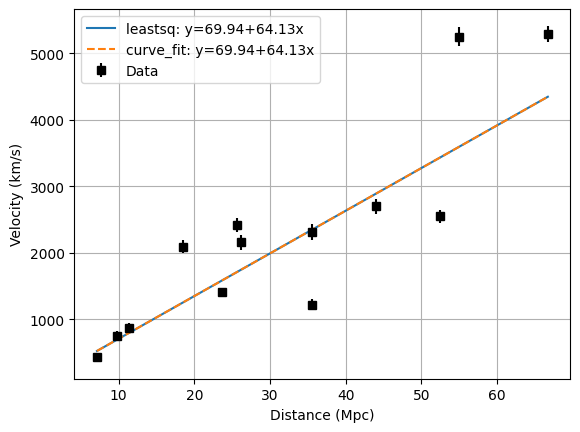

In [12]:
import numpy as np
from scipy.optimize import leastsq, curve_fit
import matplotlib.pyplot as plt

data = np.array([
    [18.49, 2094.75, 0.3, 100],
    [35.48, 2320.87, 2.2, 120],
    [35.48, 1224.9, 3.0, 80],
    [11.34, 872.13, 1.2, 80],
    [7.12, 432.2, 0.4, 70],
    [9.82, 751, 0.3, 75],
    [23.66, 1410, 2.3, 70],
    [44, 2700, 4.0, 110],
    [66.7, 5292, 5.3, 120],
    [52.4, 2550, 5.2, 100],
    [55, 5253, 6.1, 150],
    [25.6, 2419, 3.2, 110],
    [26.19, 2158, 2.8, 110]
])

d = data[:, 0]
v = data[:, 1]
v_err = data[:, 3]

def model(p, x):
    return p[0] + p[1] * x

def residuals(p, x, y, err):
    return (y - model(p, x)) / err

p0 = [0, 70]
p_leastsq, _ = leastsq(residuals, p0, args=(d, v, v_err))

def func(x, a, b):
    return a + b * x

p_curvefit, _ = curve_fit(func, d, v, p0=p0, sigma=v_err)

plt.errorbar(d, v, yerr=v_err, fmt='s', color='black', label='Data')
x_fit = np.linspace(min(d), max(d), 100)

plt.plot(x_fit, model(p_leastsq, x_fit), label=f'leastsq: y={p_leastsq[0]:.2f}+{p_leastsq[1]:.2f}x')
plt.plot(x_fit, func(x_fit, *p_curvefit), '--', label=f'curve_fit: y={p_curvefit[0]:.2f}+{p_curvefit[1]:.2f}x')

plt.xlabel('Distance (Mpc)')
plt.ylabel('Velocity (km/s)')
plt.grid()
plt.legend()
plt.show()